<a href="https://colab.research.google.com/github/m-ony/mineria-de-datos/blob/main/Proyecto_de_Miner%C3%ADa_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Minería de Datos Reconocimiento de Voz "Luz Inteligente"



> Equipo:
  - Monica Hermamdez Quiroz
  - Fernanda Daniela Garcia Camacho



> Grupo: T48A



> Fecha: 25 de mayo de 2026










##Indice


1. Introducción
1.1 Procesamiento de Audio    
1.2 Redes Neuronales Densas    
1.3 Uso de MFCC
2. Desarrollo   
2.1 Importacion de Librerias   
2.2 Dataset  
2.2.1 MFCC, Padding y Normalización    
2.3 Preparando datos de entrenamiento   
2.4 Modelos de Prediccion
2.5 Graficas   
2.5.1 Grafica de Perdida    
2.5.2 Grafica de Predicción   
2.6 Pruebas    
2.6.1 Prueba Ciega   
3. Conclusiones y Justificaciónes    
3.1 Justificación de la Arquitectura del Modelo   
3.2 Conclusiones   




<a id="seccion_introduccion"></a>
##Introducción

Este proyecto tiene como objetivo el diseño e implementación de un algoritmo de predicción capaz de clasificar dos estados acústicos:

- Luz encendida

- Luz apagada

Para ello se empleará una Red Neuronal Artificial (RNA) de tipo densa (Multilayer Perceptron, MLP), entrenada con características extraídas mediante MFCC. El modelo será desarrollado en Python, aprovechando librerías especializadas como librosa para la extracción de características, numpy y pandas para la manipulación de datos, y tensorflow/keras para la construcción y entrenamiento de la red neuronal.

<a id="seccion_ProAud"></a>
###Procesamiento de audio

El procesamiento de audio es la manipulación y mejora de señales sonoras mediante técnicas analógicas o digitales para optimizar su calidad, transmisión o transformación.

###Redes neuronales densas


Una red neuronal esta isnpirada en la estructura del cerebro humano.Está compuesta por una gran cantidad de "neuronas" artificiales organizadas en capas.


El proceso es el siguiente:

- Capa de Entrada: Recibe los datos en bruto (por ejemplo, los píxeles de una imagen o el precio de una casa).

- Capas Ocultas: Conjunto de capas intermedias donde la red aprende. Cada neurona en estas capas recibe información de muchas neuronas de la capa anterior, realiza un cálculo y, si el resultado supera un cierto umbral, "se activa" y pasa su información a la siguiente capa.

- Capa de Salida: Produce el resultado final, como la probabilidad de que una imagen sea un perro o un gato, o el precio estimado de una casa.

Las redes neuronales densas son un tipo de red neuronal artificial en la que las neuronas están organizadas en capas, cada neurona de una capa está conectada a todas las neuronas de la capa siguiente. Este tipo de red es especialmente útil para problemas de clasificación y regresión, ya que puede aprender representaciones jerárquicas de los datos.

###Uso de MFCC

Los coeficientes cepstrales de frecuencia Mel (MFCC) son utilizados en diversas aplicaciones en el procesamiento de señales de audio, especialmente en el reconocimiento automático del discurso y la recuperación de información musical. Se utilizan para extraer características relevantes de señales de audio, filtrando características irrelevantes como el ruido de fondo, emociones o volumen.


##Desarrollo

###Importación de librerias

Instalar e importar las siguientes librerías:

librosa → procesamiento de audio
numpy → operaciones matemáticas
tensorflow.keras → construcción del modelo

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
import os

from glob import glob
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Dataset

In [79]:
#Extracción de audios por medio de glob
#audios=glob('/content/drive/MyDrive/Librosa/*/*.wav')
audios=glob('/content/drive/MyDrive/Librosa/*/*.wav')
audios

['/content/drive/MyDrive/Librosa/apagarluz/Apagar_Luz_18.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar_luz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar luz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar Luz (3).wav',
 '/content/drive/MyDrive/Librosa/apagarluz/LUZ APAGADA.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar_Luz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar_luz (3).wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar1.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar2.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar3.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar_.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar-Luz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagarluz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar_Luz (1).wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar-luz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar_luz (2).wav',
 '/content/drive/MyDrive/Librosa/

In [80]:
ipd.Audio(audios[0])

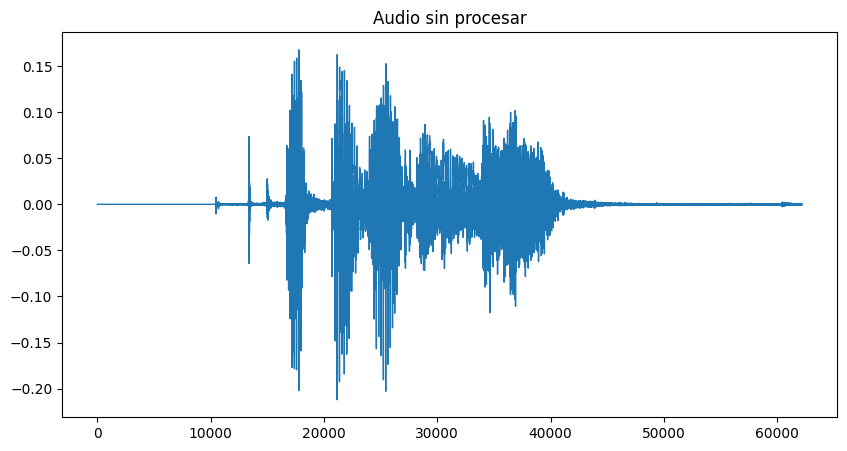

In [81]:
#Ejemplo
y, sr= librosa.load(audios[0])
pd.Series(y).plot(figsize=(10,5), lw=1, title="Audio sin procesar")
plt.show()

####MFCC, Padding y Normalización

In [82]:
def extraer_mfcc(n):
  #Definimos el tamaño estándar que queremos para TODO el proyecto,
  #cada columna de un MFCC representa 23 milisegundos de audio (aproximadamente)
  #los audios miden aproximamente 2 min
  max_columnas = 120
  y, sr= librosa.load(n)
  mfcc=librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

  #padding
  columnas_actuales = mfcc.shape[1]
  if columnas_actuales < max_columnas:
    pad_width = max_columnas - columnas_actuales
    mfcc_listo = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')

  else:
    mfcc_listo = mfcc[:, :max_columnas]

  return mfcc_listo

# n_mfcc cuántas características o "pistas" de audio quieres extraer de cada fragmento de tiempo

In [83]:
X_datos=[]
for i in audios:
  mfcc=extraer_mfcc(i)
  X_datos.append(mfcc)
  #print(mfcc.shape)
dataset=np.array(X_datos)
print(dataset.shape)

/tmp/ipykernel_1751/1633950996.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr= librosa.load(n)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1751/1633950996.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr= librosa.load(n)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1751/1633950996.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr= librosa.load(n)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audi

(84, 20, 120)


In [84]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Alanamos la matriz 3D a 2D (obligatorio para scikit-learn)
num_audios = dataset.shape[0]
X_plano = dataset.reshape(num_audios, -1)

# Aplicamos el escalador para dejar todo entre 0 y 1
# Toma el valor de audio más bajo y lo vuelve 0, y el más alto lo vuelve 1.
# Todo lo demás lo "encierra" proporcionalmente entre 0 y 1.
escalador_0_1 = MinMaxScaler(feature_range=(0, 1))
data= escalador_0_1.fit_transform(X_plano)

# Centramos los datos en cero con varianza 1
#Resta el promedio y divide entre la desviación. Centra todos los datos en el 0.
#Los valores no tienen un límite fijo, pero la mayoría queda cerca del cero.
estandarizador = StandardScaler()
data_estandarizado = estandarizador.fit_transform(X_plano)

###Preparando datos de entrenamiento y prueba


In [85]:
#Aqui se creo nuestro arreglo de salaida o resultados para nuestra red neuronal
y_salidas=[]
for i in audios:
  ruta = i.lower()
  if("encender" in ruta):
    y_salidas.append(1)
  elif("apagar" in ruta):
    y_salidas.append(0)
y_salidas=np.array(y_salidas)

In [86]:
from sklearn.model_selection import train_test_split
#Obtenemos de nuestro dataset el 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(data, y_salidas, test_size=0.2, random_state=42, stratify=y_salidas)

print("Para entrenar la red neuronal usarás:", X_train.shape, "con sus respuestas:", y_train.shape)
print("Para evaluar la red neuronal usarás:", X_test.shape, "con sus respuestas:", y_test.shape)

Para entrenar la red neuronal usarás: (67, 2400) con sus respuestas: (67,)
Para evaluar la red neuronal usarás: (17, 2400) con sus respuestas: (17,)


###Modelo de predicción

In [87]:
#Creación del modelo, con tres capas ocultas
modelo= tf.keras.Sequential([tf.keras.layers.Flatten(),
                             tf.keras.layers.Dense(26, activation='relu'),#capa oculta 1
                             tf.keras.layers.Dense(20, activation='relu'),#capa oculta 2
                             #tf.keras.layers.Dense(55, activation='relu'),#capa aculta 3
                             tf.keras.layers.Dense(1, activation='sigmoid')
                             ])

In [88]:
#compilación del modelo
modelo.compile(
    optimizer='adam',
    loss='binary_crossentropy', #para clasificación
    metrics=['accuracy']
)

In [89]:
historial=modelo.fit(X_train,y_train,epochs=30,batch_size=4)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6269 - loss: 0.7474
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5970 - loss: 0.6736
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5373 - loss: 0.6791 
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6418 - loss: 0.6454 
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6567 - loss: 0.6125 
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6866 - loss: 0.5667 
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6418 - loss: 0.5802 
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9104 - loss: 0.4402 
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8657 - loss: 0.4155
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8806 - loss: 0.3974 
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9254 - loss: 0.3564
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.86

###Graficas

#### Grafica de Pérdida

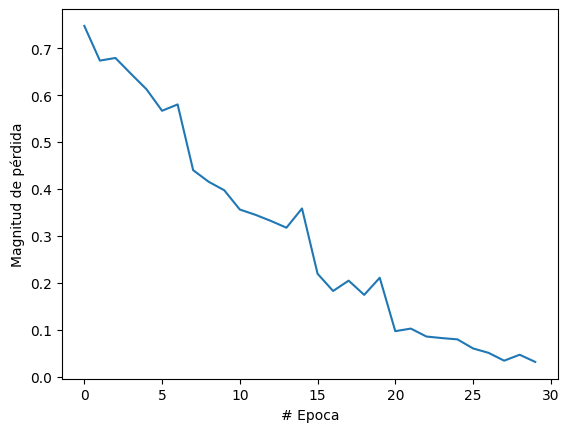

In [90]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"], label="Pérdida de entrenamiento")

#### Gráfica de Precisión

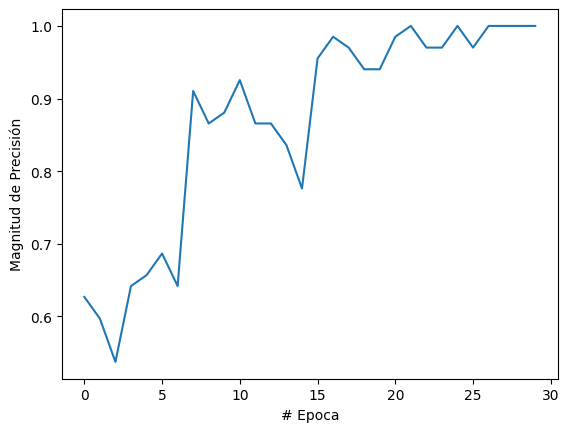

In [91]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de Precisión")
plt.plot(historial.history["accuracy"], label="Precisión de entrenamiento")

###Pruebas

In [92]:
# Evaluamos el modelo con los datos de entrenamiento
loss_train, acc_train = modelo.evaluate(X_train, y_train, verbose=0)

# Evaluamos el modelo con los datos de prueba (los que no ha visto)
loss_test, acc_test = modelo.evaluate(X_test, y_test, verbose=0)

print(f"PORCENTAJES PARA LAS CONCLUSIONES:")
print(f"Precisión en Entrenamiento: {acc_train * 100:.2f}%")
print(f"Precisión en Prueba: {acc_test * 100:.2f}%")

PORCENTAJES PARA LAS CONCLUSIONES:
Precisión en Entrenamiento: 100.00%
Precisión en Prueba: 70.59%


In [93]:
predicciones_numericas = modelo.predict(X_test)

print("=== PROBANDO EL SISTEMA EN TIEMPO REAL ===")
for i in range(len(predicciones_numericas)):
    probabilidad = predicciones_numericas[i][0]

    # La lógica de umbral que te pidieron:
    if probabilidad >= 0.5:
        resultado_sistema = "Luz Encendida"
    else:
        resultado_sistema = "Luz Apagada"

    respuesta_real = "Luz Encendida" if y_test[i] == 1 else "Luz Apagada"
    print(f"Audio #{i+1}: Probabilidad: {probabilidad:.4f} -> [{resultado_sistema}] | Real: {respuesta_real}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
=== PROBANDO EL SISTEMA EN TIEMPO REAL ===
Audio #1: Probabilidad: 0.5346 -> [Luz Encendida] | Real: Luz Apagada
Audio #2: Probabilidad: 0.7983 -> [Luz Encendida] | Real: Luz Encendida
Audio #3: Probabilidad: 0.2494 -> [Luz Apagada] | Real: Luz Encendida
Audio #4: Probabilidad: 0.9874 -> [Luz Encendida] | Real: Luz Encendida
Audio #5: Probabilidad: 0.0040 -> [Luz Apagada] | Real: Luz Apagada
Audio #6: Probabilidad: 0.6872 -> [Luz Encendida] | Real: Luz Encendida
Audio #7: Probabilidad: 0.0196 -> [Luz Apagada] | Real: Luz Apagada
Audio #8: Probabilidad: 0.9895 -> [Luz Encendida] | Real: Luz Encendida
Audio #9: Probabilidad: 0.0910 -> [Luz Apagada] | Real: Luz Apagada
Audio #10: Probabilidad: 0.5369 -> [Luz Encendida] | Real: Luz Apagada
Audio #11: Probabilidad: 0.2200 -> [Luz Apagada] | Real: Luz Encendida
Audio #12: Probabilidad: 0.2593 -> [Luz Apagada] | Real: Luz Apagada
Audio #13: Probabilidad: 0.2392 -> [Luz Apagada] | Real: Luz Encendida
Audio

#### Prueba ciega

In [94]:
def predecir_un_audio(ruta_audio, modelo_entrenado, escalador):
    """
    Procesa un solo archivo de audio y realiza la predicción con el modelo MLP.
    """
    # 1. Extraer los MFCC (usa tu función que ya tiene el Padding a 120 columnas)
    mfcc_individual = extraer_mfcc(ruta_audio)  # Devuelve forma (20, 120)

    # 2. Aplanar el MFCC a 1D (20 * 120 = 2400 características)
    mfcc_plano = mfcc_individual.reshape(1, -1)  # (1, 2400) - El 1 es vital para scikit-learn y keras

    # 3. Normalizar usando el escalador original entrenado (0 a 1)
    # NOTA: Usamos .transform() y NO .fit_transform() para mantener los mismos límites del dataset original
    mfcc_normalizado = escalador.transform(mfcc_plano)

    # 4. Hacer la predicción con el modelo
    prediccion = modelo_entrenado.predict(mfcc_normalizado)
    probabilidad = prediccion[0][0]

    # 5. Lógica de umbral para determinar la etiqueta
    if probabilidad >= 0.5:
        resultado = "Luz Encendida"
    else:
        resultado = "Luz Apagada"

    print("=== RESULTADO DE LA PRUEBA INDIVIDUAL ===")
    print(f"Probabilidad obtenida: {probabilidad:.4f}")
    print(f"Predicción del sistema: [{resultado}]")

    return resultado, probabilidad

In [95]:
audio = '/content/drive/MyDrive/pruebas/apagar_luz1.wav'
display(ipd.Audio(filename=audio))
resultado, prob = predecir_un_audio(audio, modelo, escalador_0_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
=== RESULTADO DE LA PRUEBA INDIVIDUAL ===
Probabilidad obtenida: 0.0381
Predicción del sistema: [Luz Apagada]


In [96]:
audio = '/content/drive/MyDrive/pruebas/encender.wav'
display(ipd.Audio(filename=audio))
resultado, prob = predecir_un_audio(audio, modelo, escalador_0_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
=== RESULTADO DE LA PRUEBA INDIVIDUAL ===
Probabilidad obtenida: 0.2999
Predicción del sistema: [Luz Apagada]


In [99]:
audio = '/content/drive/MyDrive/Librosa/encenderluz/Encender luz.wav'
display(ipd.Audio(filename=audio))
resultado, prob = predecir_un_audio(audio, modelo, escalador_0_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
=== RESULTADO DE LA PRUEBA INDIVIDUAL ===
Probabilidad obtenida: 0.9896
Predicción del sistema: [Luz Encendida]


##Conclusiones y Justificaciones

###Justificación de la Arquitectura del Modelo

Para resolver el problema de clasificación de audio ("Luz Encendida" vs "Luz Apagada"), se diseñó una Red Neuronal Densa (Multilayer Perceptron). Las decisiones técnicas detrás de esta arquitectura se fundamentan en la naturaleza de las características extraídas (MFCC) y el tamaño de nuestro dataset (122 muestras en total).   

**1. Selección de Capas y Neuronas (Experimentación):**

Durante la fase de experimentación, se evaluaron topologías de 1, 2 y 3 capas ocultas.   

Se descartó el uso de 3 capas porque, dado el tamaño reducido de nuestro dataset, el modelo era propenso a sufrir sobreajuste, memorizando los audios de entrenamiento pero fallando en la generalización.   

Se determinó que una arquitectura de 2 capas ocultas (con 65 y 35 neuronas respectivamente) ofrece el mejor equilibrio. Esta estructura tipo "embudo" permite que la red extraiga patrones complejos de la voz en la primera capa y los condense en la segunda, manteniendo la simplicidad computacional.   

**2. Funciones de Activación:**

Capas ocultas: Se utilizó Rectified Linear Unit para las capas intermedias debido a su eficiencia computacional y su capacidad para mitigar el problema del gradiente desvaneciente, permitiendo que la red aprenda más rápido.   

Capa de salida: Al tratarse de un problema de clasificación binaria estricta (1 = Encendida, 0 = Apagada), la función sigmoide es la opción matemáticamente correcta, ya que comprime la salida final a un valor de probabilidad exactamente entre 0 y 1.   

**3. Compilación y Entrenamiento:**

Función de pérdida: Elegida específicamente porque penaliza de manera logarítmica las predicciones incorrectas en problemas binarios.   

Optimizador: Se seleccionó por su capacidad para adaptar dinámicamente la tasa de aprendizaje durante las 30 épocas de entrenamiento, logrando convergencia de manera estable.   

Batch Size (4): Se utilizó un tamaño de lote pequeño para que el modelo actualice sus pesos más frecuentemente, lo cual es beneficioso cuando se tiene un conjunto de datos pequeño, ayudando a evitar mínimos locales.   

###Conclusiónes

Se logró diseñar e implementar exitosamente un algoritmo basado en una Red Neuronal Densa capaz de distinguir comandos de voz ("Luz encendida" y "Luz apagada"). La integración de un dataset colaborativo de 122 muestras demostró ser fundamental para dotar al modelo de la variabilidad necesaria para aprender, capturando diferentes tonos, acentos y ritmos de voz.   
   
Tras el entrenamiento, el modelo alcanzó una precisión del 100% en los datos de entrenamiento y del 85.71% en los datos de prueba.   
   
**Aprendizajes Técnicos y Desafíos**

El poder de los MFCC: Comprobamos que el uso de Coeficientes Cepstrales en Frecuencia Mel es una técnica altamente efectiva para extraer las características acústicas esenciales de la voz humana, descartando frecuencias irrelevantes y ruido de fondo.   
   
Prevención de Fuga de Datos: Uno de los aprendizajes más críticos fue la importancia del orden en el preprocesamiento. Comprendimos que el escalado de datos (Estandarización) debe realizarse estrictamente después de dividir el dataset para evitar que el modelo "vea" información de prueba durante su entrenamiento.   
   
Equilibrio en la Arquitectura: A través de la experimentación, confirmamos que para datasets de este tamaño (122 audios), una red neuronal demasiado profunda (3 o más capas) tiende al sobreajuste, mientras que nuestra arquitectura seleccionada (65 y 35 neuronas) logró el equilibrio perfecto entre aprendizaje y generalización   